# 位置编码

> 上一节，我们用 Embedding 把 token ID 变成了向量——每个 token ID 查表得到一个固定的高维向量。但这里有一个问题：同一个 token 不管出现在句子的哪个位置，查出的向量完全相同。换句话说，模型此时无法区分 "the cat" 和 "cat the"。
>
> 这一节引入 Position Encoding，给每个位置准备一个独特的向量，加到 Token Embedding 上。我们从具体例子出发，先看清楚没有位置信息时模型会遇到什么问题，再一步步推导出正弦位置编码的方案，最后组装出完整的 Transformer 输入层。

"猫追狗"和"狗追猫"包含完全相同的三个字，但因为顺序不同，意思截然相反。"你喜欢我"和"我喜欢你"也只有两个字调换了位置，前者是对方喜欢自己，后者是自己喜欢对方。英文也是如此："the cat sat" 是一只猫坐下了，"sat the cat" 则不太像正常的句子。

这些例子指向一个共同的事实：相同的 token 在不同的位置可能承担不同的角色，模型如果不知道位置，就无法理解这种差异。

## 1. 为什么需要位置信息

但上一节实现的 Embedding 层实际上不包含任何位置信息：查表时只看 token ID，不看位置。同一个 ID 不管出现在第几个位置，从矩阵里取出的都是同一行。下面的代码验证了这一点。

In [1]:
import torch
import torch.nn as nn

# 用一个极小的 Embedding 来验证：同一个 token 在不同位置，向量是否相同
torch.manual_seed(42)

vocab_size = 10    # 10 个 token
d_model = 4       # 4 维向量，方便打印观察

emb_table = nn.Embedding(vocab_size, d_model)

# 构造一个输入：token 0 出现在位置 0 和位置 3
# 另外放几个不同的 token 在中间
input_ids = torch.tensor([[0, 2, 5, 0, 7]])  # [batch=1, seq_len=5]

vectors = emb_table(input_ids)  # [1, 5, 4]

print("=== 输入 token ID ===")
print(input_ids)
print(f"\n=== Embedding 查表结果 (shape: {vectors.shape}) ===")
for pos in range(5):
    tid = input_ids[0, pos].item()
    vec = vectors[0, pos].detach()
    print(f"位置 {pos}, token {tid}: {vec.tolist()}")

print(f"\n=== 关键观察 ===")
v0 = vectors[0, 0].detach()
v3 = vectors[0, 3].detach()
print(f"位置 0 的 token 0: {v0.tolist()}")
print(f"位置 3 的 token 0: {v3.tolist()}")
print(f"两者相同? {torch.equal(v0, v3)}")
print(f"\ntoken 0 在位置 0 和位置 3 得到了完全相同的向量。")
print(f"模型在这个阶段无法区分它们所在的位置。")


=== 输入 token ID ===
tensor([[0, 2, 5, 0, 7]])

=== Embedding 查表结果 (shape: torch.Size([1, 5, 4])) ===
位置 0, token 0: [1.9269152879714966, 1.4872840642929077, 0.9007171988487244, -2.1055209636688232]
位置 1, token 2: [-0.7521352767944336, 1.6487230062484741, -0.3924786448478699, -1.4036071300506592]
位置 2, token 5: [-0.7581311464309692, 1.078317642211914, 0.8008005619049072, 1.680620551109314]
位置 3, token 0: [1.9269152879714966, 1.4872840642929077, 0.9007171988487244, -2.1055209636688232]
位置 4, token 7: [1.312307596206665, 0.6871595978736877, -1.0891753435134888, -0.3552866280078888]

=== 关键观察 ===
位置 0 的 token 0: [1.9269152879714966, 1.4872840642929077, 0.9007171988487244, -2.1055209636688232]
位置 3 的 token 0: [1.9269152879714966, 1.4872840642929077, 0.9007171988487244, -2.1055209636688232]
两者相同? True

token 0 在位置 0 和位置 3 得到了完全相同的向量。
模型在这个阶段无法区分它们所在的位置。


输出证实了问题：在只做 token embedding 查表时，同一个 token 在位置 0 和位置 3 的向量完全相同。对模型来说，这两个位置上的 "the" 是不可区分的。

这个问题的严重程度取决于语序在语言中扮演的角色。在中文里，"我喜欢你"和"你喜欢我"包含的 token 完全一样，但含义取决于谁在前、谁在后。英文中 "dog bites man" 是新闻，"man bites dog" 就是大新闻。日语的语序和中文、英文都不同，但词与词之间的语法关系同样由位置标记。无论哪种语言，位置信息都不是可有可无的装饰——它是理解句子结构的基础。

因此，在把 token ID 序列送入 Transformer 之前，需要额外附加位置信息。接下来的问题是：用什么方式表示位置。


## 2. 正弦位置编码

### 从最直接的方案开始

给每个位置一个标识，最直接的想法是直接用位置编号。位置 0 的向量是 `[0, 0, 0, ...]`，位置 1 是 `[1, 1, 1, ...]`，位置 100 是 `[100, 100, 100, ...]`。先把这个方案实现出来，看看它有什么问题。


In [2]:
import torch

# 方案一：直接用位置编号作为位置向量
def get_naive_encoding(seq_len, d_model):
    """最朴素的位置编码：每个维度直接填位置编号"""
    pe = torch.zeros(seq_len, d_model)
    for pos in range(seq_len):
        pe[pos, :] = pos  # 所有维度都填 pos
    return pe

naive_pe = get_naive_encoding(seq_len=10, d_model=4)
print("=== 方案一：直接用位置编号 ===")
print(naive_pe)
print()
print("问题 1：值随位置增长")
print(f"  位置 0 的值: {naive_pe[0].tolist()}, 模长 = {naive_pe[0].norm():.2f}")
print(f"  位置 5 的值: {naive_pe[5].tolist()}, 模长 = {naive_pe[5].norm():.2f}")
print(f"  位置 9 的值: {naive_pe[9].tolist()}, 模长 = {naive_pe[9].norm():.2f}")
print(f"  → 模长从 0 增长到 {naive_pe[9].norm():.2f}，差异很大")
print(f"  → 神经网络更适合处理有界的数值，而不是无限增长的值")
print()
print("问题 2：所有维度携带相同信息")
print(f"  每个位置 4 个维度值相同，相当于只有 1 个有效信息源")
print(f"  → 浪费了 d_model 维空间")

=== 方案一：直接用位置编号 ===
tensor([[0., 0., 0., 0.],
        [1., 1., 1., 1.],
        [2., 2., 2., 2.],
        [3., 3., 3., 3.],
        [4., 4., 4., 4.],
        [5., 5., 5., 5.],
        [6., 6., 6., 6.],
        [7., 7., 7., 7.],
        [8., 8., 8., 8.],
        [9., 9., 9., 9.]])

问题 1：值随位置增长
  位置 0 的值: [0.0, 0.0, 0.0, 0.0], 模长 = 0.00
  位置 5 的值: [5.0, 5.0, 5.0, 5.0], 模长 = 10.00
  位置 9 的值: [9.0, 9.0, 9.0, 9.0], 模长 = 18.00
  → 模长从 0 增长到 18.00，差异很大
  → 神经网络更适合处理有界的数值，而不是无限增长的值

问题 2：所有维度携带相同信息
  每个位置 4 个维度值相同，相当于只有 1 个有效信息源
  → 浪费了 d_model 维空间


直接用编号有两个明显的缺陷：值会随位置无限增长，而且所有维度携带相同的信息。

一种改进思路是给每个位置学一个向量（learnable position embedding），GPT 系列用的就是这种方式。它的局限是只能表示训练时见过的最大长度——如果训练时最长处理 512 个 token，遇到第 513 个位置就没有参考了。

Transformer 原始论文选择了另一种方案：用 sin 和 cos 函数手工构造位置向量。选择三角函数的理由有三点：

1. **值有界**：sin 和 cos 的值始终在 [-1, 1] 之间，不会随位置增长而发散。
2. **可以外推**：因为是连续函数，训练时没见过的位置也能直接算出编码。
3. **隐含相对位置关系**：利用三角恒等式，位置 pos+k 的编码可以用位置 pos 的编码经过线性变换得到。这意味着模型有可能学到"两个 token 隔了多远"，而不仅仅是绝对位置编号。

公式如下：

$$
PE(pos, 2i) = \sin\left(\frac{pos}{10000^{2i/d}}\right), \quad
PE(pos, 2i+1) = \cos\left(\frac{pos}{10000^{2i/d}}\right)
$$

其中 pos 是位置编号，i 是维度编号，d 是向量总维度。偶数维度用 sin，奇数维度用 cos。

不急着记住公式。先用一组具体数字手动算一遍，看看这个编码到底长什么样。


In [3]:
import math
import torch

# 手算：d_model=4, 位置 0-3 的位置编码
# 公式：PE(pos, 2i) = sin(pos / 10000^(2i/d))
#       PE(pos, 2i+1) = cos(pos / 10000^(2i/d))

d = 4  # 总维度

print("=== 参数计算 ===")
print(f"d_model = {d}")
print()

# 先算每一对维度对应的分母 10000^(2i/d)
for i in range(d // 2):
    freq = 10000 ** (2 * i / d)
    print(f"维度对 {i}: 10000^({2*i}/{d}) = 10000^{2*i/d:.1f} = {freq:.4f}")

print()
print("=== 逐位置计算 ===")
for pos in range(4):
    print(f"\n位置 {pos}:")
    for i in range(d // 2):
        freq = 10000 ** (2 * i / d)
        val_sin = math.sin(pos / freq)
        val_cos = math.cos(pos / freq)
        print(f"  维度 {2*i} (sin): sin({pos} / {freq:.4f}) = sin({pos/freq:.4f}) = {val_sin:.4f}")
        print(f"  维度 {2*i+1} (cos): cos({pos} / {freq:.4f}) = cos({pos/freq:.4f}) = {val_cos:.4f}")

print()
print("=== 汇总表 ===")
# 用函数来对照
pe_small = torch.zeros(4, d)
position = torch.arange(4).unsqueeze(1).float()
div_term = torch.exp(torch.arange(0, d, 2).float() * (-math.log(10000.0) / d))
pe_small[:, 0::2] = torch.sin(position * div_term)
pe_small[:, 1::2] = torch.cos(position * div_term)
header = f"{'位置':>4} | {'dim 0 (sin)':>12} | {'dim 1 (cos)':>12} | {'dim 2 (sin)':>12} | {'dim 3 (cos)':>12}"
print(header)
print("-" * len(header))
for pos in range(4):
    vals = " | ".join(f"{pe_small[pos, j]:>12.6f}" for j in range(d))
    print(f"{pos:>4} | {vals}")
print()
print("关键观察：")
print(f"  维度 0-1 的分母 = 1.0 → 波长 = 2π ≈ 6.28，变化快，区分相邻位置")
print(f"  维度 2-3 的分母 = 100.0 → 波长 = 200π ≈ 628，变化慢，传递远距离关系")
print(f"  不同维度以不同速度变化，组合起来给每个位置一个独特的\"指纹\"")


=== 参数计算 ===
d_model = 4

维度对 0: 10000^(0/4) = 10000^0.0 = 1.0000
维度对 1: 10000^(2/4) = 10000^0.5 = 100.0000

=== 逐位置计算 ===

位置 0:
  维度 0 (sin): sin(0 / 1.0000) = sin(0.0000) = 0.0000
  维度 1 (cos): cos(0 / 1.0000) = cos(0.0000) = 1.0000
  维度 2 (sin): sin(0 / 100.0000) = sin(0.0000) = 0.0000
  维度 3 (cos): cos(0 / 100.0000) = cos(0.0000) = 1.0000

位置 1:
  维度 0 (sin): sin(1 / 1.0000) = sin(1.0000) = 0.8415
  维度 1 (cos): cos(1 / 1.0000) = cos(1.0000) = 0.5403
  维度 2 (sin): sin(1 / 100.0000) = sin(0.0100) = 0.0100
  维度 3 (cos): cos(1 / 100.0000) = cos(0.0100) = 1.0000

位置 2:
  维度 0 (sin): sin(2 / 1.0000) = sin(2.0000) = 0.9093
  维度 1 (cos): cos(2 / 1.0000) = cos(2.0000) = -0.4161
  维度 2 (sin): sin(2 / 100.0000) = sin(0.0200) = 0.0200
  维度 3 (cos): cos(2 / 100.0000) = cos(0.0200) = 0.9998

位置 3:
  维度 0 (sin): sin(3 / 1.0000) = sin(3.0000) = 0.1411
  维度 1 (cos): cos(3 / 1.0000) = cos(3.0000) = -0.9900
  维度 2 (sin): sin(3 / 100.0000) = sin(0.0300) = 0.0300
  维度 3 (cos): cos(3 / 100.0000) = cos(

手算结果清楚地展示了正弦位置编码的工作方式。把刚才的观察整理一下：

每个维度对应一条正弦波（或余弦波）。维度编号越小，分母越小，波的频率越高——位置稍微移动，值就变化明显，适合区分相邻位置。维度编号越大，分母越大，波的频率越低——值变化缓慢，适合传递远距离的位置关系。

举个直观的比方：低频维度像时钟的时针，变化慢，告诉我们大致在哪个时间段；高频维度像秒针，变化快，告诉我们精确的时刻。两种信息组合起来，就能唯一确定一个时刻。正弦位置编码也是这个道理：不同频率的波组合起来，给每个位置生成一个独特的向量。

用 10000 作为底数是原论文的经验选择。底数越大，高频和低频之间的频率差距越大，编码能覆盖的位置范围就越广。10000 在常见的序列长度（几十到几千个 token）范围内表现良好。

接下来把完整的编码函数实现出来，并用更大的参数看看编码的整体面貌。


In [4]:
import math
import torch

def get_sinusoidal_encoding(seq_len, d_model):
    """
    正弦位置编码：每个位置用不同频率的 sin/cos 波生成唯一向量
    
    PE(pos, 2i)   = sin(pos / 10000^(2i/d))
    PE(pos, 2i+1) = cos(pos / 10000^(2i/d))
    """
    position = torch.arange(seq_len).unsqueeze(1)  # [seq_len, 1]
    div_term = torch.exp(
        torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
    )
    pe = torch.zeros(seq_len, d_model)
    pe[:, 0::2] = torch.sin(position * div_term)   # 偶数维 sin
    pe[:, 1::2] = torch.cos(position * div_term)   # 奇数维 cos
    return pe

# 生成 10 个位置、8 维的编码
pe = get_sinusoidal_encoding(seq_len=10, d_model=8)
print(f"位置编码形状: {pe.shape}  ← 10 个位置 × 每个位置 8 维")
print(f"前 3 个位置的编码:\n{pe[:3]}")

位置编码形状: torch.Size([10, 8])  ← 10 个位置 × 每个位置 8 维
前 3 个位置的编码:
tensor([[ 0.0000e+00,  1.0000e+00,  0.0000e+00,  1.0000e+00,  0.0000e+00,
          1.0000e+00,  0.0000e+00,  1.0000e+00],
        [ 8.4147e-01,  5.4030e-01,  9.9833e-02,  9.9500e-01,  9.9998e-03,
          9.9995e-01,  1.0000e-03,  1.0000e+00],
        [ 9.0930e-01, -4.1615e-01,  1.9867e-01,  9.8007e-01,  1.9999e-02,
          9.9980e-01,  2.0000e-03,  1.0000e+00]])


**看图：位置编码长什么样**

上面打印的数字不太容易看出规律。下面把 50 个位置、32 个维度的编码画出来。左图是热力图，每一行是一个位置，每一列是一个维度，颜色代表值的大小。右图选了几个维度，画出它们的值随位置变化的曲线——可以看到不同维度以不同频率波动。


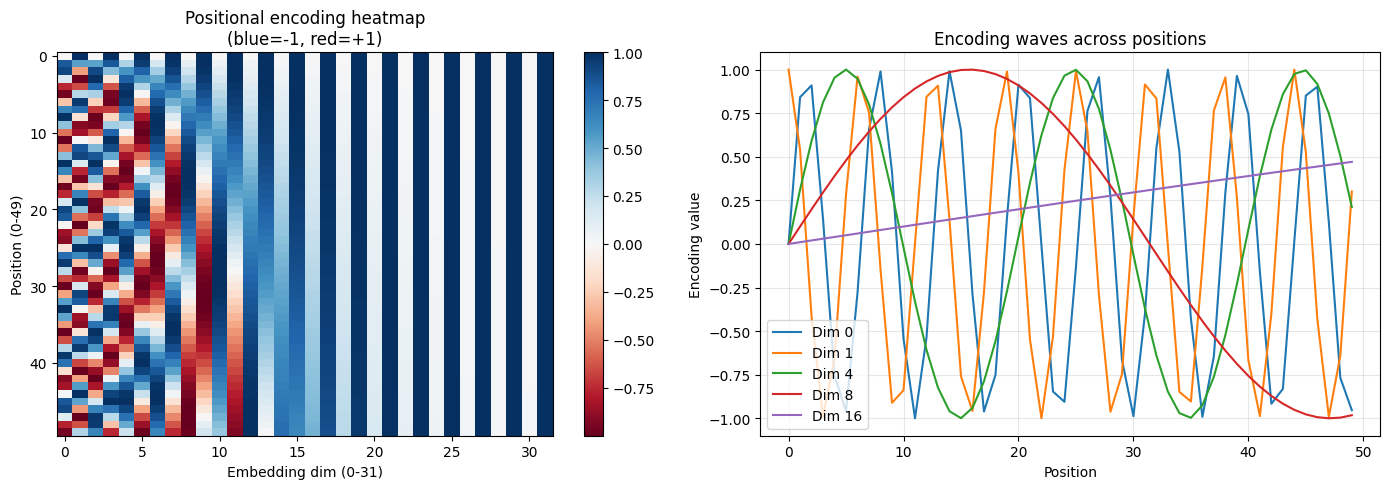

In [5]:
import matplotlib.pyplot as plt

# 可视化位置编码：热力图 + 波形图
pe_viz = get_sinusoidal_encoding(seq_len=50, d_model=32)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左: 热力图 — 横轴=维度, 纵轴=位置, 色=值
im = axes[0].imshow(pe_viz.numpy(), aspect='auto', cmap='RdBu')
axes[0].set_xlabel('Embedding dim (0-31)'); axes[0].set_ylabel('Position (0-49)')
axes[0].set_title('Positional encoding heatmap\n(blue=-1, red=+1)')
plt.colorbar(im, ax=axes[0])

# 右: 选几个维度，看它们的值随位置怎么变
# 低维度波长短（变化快→区分邻居），高维度波长长（变化慢→区分远处）
for dim_idx in [0, 1, 4, 8, 16]:
    axes[1].plot(range(50), pe_viz[:, dim_idx].numpy(), label=f'Dim {dim_idx}')
axes[1].set_xlabel('Position'); axes[1].set_ylabel('Encoding value')
axes[1].set_title('Encoding waves across positions')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


**热力图怎么读**

左图横轴是维度编号（0-31），纵轴是位置编号（0-49），颜色表示编码值：红色接近 +1，蓝色接近 -1。

最显眼的特征是左半边密、右半边疏，中间有一条弧线。回忆公式 $PE(pos, 2i) = \sin(pos / 10000^{2i/d})$：维度编号 $i$ 越大，分母越大，波长越长。在 50 个位置的范围内，不同维度的表现差异很大：

- **dim 0-7（左半边）**：波长短（约 6-15），50 个位置能容纳 3-8 个完整的 sin/cos 周期，红蓝颜色交替形成密集的条纹
- **dim 8-15（中间）**：波长变长（约 60-150），50 个位置不够完成一个完整周期。sin/cos 只走完了上升或下降的一段，在热力图上呈现为一条弧线——它本质上是一条没走完的半波
- **dim 16-31（右半边）**：波长极长（600 以上），50 个位置的范围内值几乎没有变化，热力图上表现为均匀的色块

那条"外弧线"的成因可以这样理解：分母 $10000^{2i/d}$ 随 $i$ **指数增长**，所以频率从高到低的下降不是匀速的。从 dim 0 到 dim 8，频率已经下降了约 10 倍（从约 1 降到约 0.1）；而从 dim 8 到 dim 16，又下降了 10 倍。在 dim 8-14 这个区间里，每个维度的波刚好只走了上升或下降的一段弧，这些没走完的半波拼在一起，就形成了那条向外凸起的曲线。

右图的曲线可以对照着验证。维度 0（蓝线）在 50 个位置里来回振荡了约 8 次；维度 8（红线）只走了不到半个上升段；维度 16（紫线）几乎是一条直线。想象把这些曲线竖起来并排放在一起，就还原了左边热力图的全貌。

**为什么需要这么多不同频率？** 热力图上从密到疏的渐变不是偶然的——它和二进制计数的原理相同。用二进制表示 0-15：

```
 0: 0 0 0 0     4: 0 1 0 0     8: 1 0 0 0    12: 1 1 0 0
 1: 0 0 0 1     5: 0 1 0 1     9: 1 0 0 1    13: 1 1 0 1
 2: 0 0 1 0     6: 0 1 1 0    10: 1 0 1 0    14: 1 1 1 0
 3: 0 0 1 1     7: 0 1 1 1    11: 1 0 1 1    15: 1 1 1 1
```

先看左侧第一组（0-3）。每行有四个数字，假设只看最右列：`0, 1, 0, 1` — 每走一步就在 0 和 1 之间切换。再看右数第二列：`0, 0, 1, 1` — 每两步才切换一次。再往左看：`0, 0, 0, 0` — 四步之内连一次翻转都没出现，需要看更多数字才能观察到变化。

把视角扩展到全部 16 个数，每一列的完整翻转模式就清楚了：

- **bit 0**（最右列）：`0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1` — 每走一步切换一次，周期为 2。
- **bit 1**（右数第二列）：`0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1` — 每走两步切换一次，周期为 4。
- **bit 2**（右数第三列）：`0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1` — 每走四步切换一次，周期为 8。
- **bit 3**（最左列）：`0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1` — 每走八步切换一次，周期为 16。

每往左移一个 bit 位，翻转速度就慢一倍：周期从 2 翻倍到 4、8、16。单独看任何一位，它只能给出 0 或 1 两个值，信息量有限。但四个 bit 位以不同速度变化的 0/1 组合在一起，就能为 0 到 15 的每个数字给出唯一的编码。验证一下：表格里从上到下依次是 0 到 15 的二进制，没有哪两行完全相同。

正弦位置编码做的事情完全一样，只不过把 0/1 的离散翻转换成了连续的 sin/cos 振荡。热力图左边的低维度对应二进制的低位——变化快，每走一步值就不同；右边的高维度对应高位——变化慢，要走很远值才有明显变化。这种设计有两个直接好处。

第一，每个位置得到一个独一无二的向量（就像每个整数有唯一的二进制表示）。

第二，三角函数的恒等式 $\sin(a+b) = \sin a \cos b + \cos a \sin b$（余弦类似）带来了一项特殊性质：位置 pos+k 的编码可以由位置 pos 的编码经过一次线性变换得到，而这次变换只依赖于距离 k，与绝对位置 pos 无关。这意味着什么？假设模型看到了两个 token 的位置编码向量，如果它能识别这两个向量之间的变换关系，就能推断出它们隔了多远——不管它们出现在句子的第几个位置。换句话说，模型不必记住"这个词在第 5 位，那个词在第 7 位"，而是有机会直接学到"这两个词隔了 2 个位置"。

> 二进制类比来自 Kazemnejad 的博文 [Transformer Architecture: The Positional Encoding](https://kazemnejad.com/transformer_architecture_positional_encoding/)，该文对正弦位置编码的直觉解释非常清晰。

In [6]:
# 逐列打印二进制的翻转规律，直观感受"不同速度变化 → 唯一表示"
print("=== 二进制 0-15 的四列翻转模式 ===\n")
print(f"{'十进制':>4}  {'bit3':>4}  {'bit2':>4}  {'bit1':>4}  {'bit0':>4}")
print("-" * 32)
for n in range(16):
    bits = f"{n:04b}"
    print(f"{n:>4}  {bits[0]:>4}  {bits[1]:>4}  {bits[2]:>4}  {bits[3]:>4}")

print()
print("=== 每列的翻转周期 ===")
for bit in range(4):
    pattern = "".join(str((n >> bit) & 1) for n in range(16))
    period = 2 ** (bit + 1)
    half = period // 2
    print(f"  bit {bit}: {pattern}  → 每 {half} 步翻转, 周期 = {period}")

print()
print("四列的周期分别是 2、4、8、16，每次翻倍。")
print("正弦编码的波长也按同样的规律指数增长，只不过用连续值代替了 0/1。")

=== 二进制 0-15 的四列翻转模式 ===

 十进制  bit3  bit2  bit1  bit0
--------------------------------
   0     0     0     0     0
   1     0     0     0     1
   2     0     0     1     0
   3     0     0     1     1
   4     0     1     0     0
   5     0     1     0     1
   6     0     1     1     0
   7     0     1     1     1
   8     1     0     0     0
   9     1     0     0     1
  10     1     0     1     0
  11     1     0     1     1
  12     1     1     0     0
  13     1     1     0     1
  14     1     1     1     0
  15     1     1     1     1

=== 每列的翻转周期 ===
  bit 0: 0101010101010101  → 每 1 步翻转, 周期 = 2
  bit 1: 0011001100110011  → 每 2 步翻转, 周期 = 4
  bit 2: 0000111100001111  → 每 4 步翻转, 周期 = 8
  bit 3: 0000000011111111  → 每 8 步翻转, 周期 = 16

四列的周期分别是 2、4、8、16，每次翻倍。
正弦编码的波长也按同样的规律指数增长，只不过用连续值代替了 0/1。


### 为什么用加法而不是拼接

位置信息有了，接下来要决定怎么把它和 Token Embedding 组合。最直观的两种方式是加法和拼接（concatenation）。

拼接的做法是把 token 向量和位置向量首尾相连，拼成一个更长的向量。比如 token 向量是 4 维，位置向量也是 4 维，拼接后变成 8 维。这样信息确实不会混淆，但维度翻倍意味着后续每一层的参数量和计算量都要乘以 2。

加法的做法更简洁：直接把两个向量逐元素相加，维度保持不变。这样做的前提是，后续的线性层（和 Attention 层）有能力从相加后的向量中同时提取 token 信息和位置信息——因为线性变换可以学会区分相加的两个信号。

标准 Transformer 选择了加法。这主要出于效率考虑：维度不增加，计算量不膨胀。实践证明，只要训练充分，加法方案的效果并不逊于拼接。

## 3. 组装：Token Embedding + Position Encoding

现在把 Token Embedding 和 Position Encoding 合在一起，做成一个 PyTorch Module。

输入是 token ID：`[batch_size, seq_len]`

输出是向量：`[batch_size, seq_len, embed_dim]`

每个样本的每个位置都有一个向量，它同时包含了 token 的语义信息和位置信息。


In [7]:
import torch
import torch.nn as nn

class TokenEmbedding(nn.Module):
    """Token ID → 向量：Embedding 查表 + 位置编码"""
    
    def __init__(self, vocab_size, d_model, max_seq_len=512):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model)
        # Position Encoding 手工算，不参与训练（register_buffer）
        pe = get_sinusoidal_encoding(max_seq_len, d_model)
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        # x: [batch, seq_len] → output: [batch, seq_len, d_model]
        seq_len = x.shape[1]
        token_vecs = self.token_emb(x)         # 查表
        pos_vecs = self.pe[:seq_len, :]        # 取对应位置编码
        return token_vecs + pos_vecs            # 加法（不是拼接）

# 测试：用固定输入，确保同一个 token 出现在不同位置
test_vocab_size, test_d_model = 20, 8
emb_module = TokenEmbedding(test_vocab_size, test_d_model)

# token 0 同时出现在位置 0 和位置 3
test_input = torch.tensor([
    [0, 1, 2, 0, 3],   # 同一个 token(0) 在位置 0 和位置 3
    [5, 4, 0, 6, 0],   # 同一个 token(0) 在位置 2 和位置 4
])
output = emb_module(test_input)

print(f"输入:\n{test_input}")
print(f"输出形状: {output.shape}  → [batch=2, seq_len=5, d_model={test_d_model}]")

# 验证：batch 0 中，位置 0 和位置 3 都是 token 0
tid_0 = test_input[0, 0].item()
tid_3 = test_input[0, 3].item()
print(f"\n位置 0 的 token ID = {tid_0}，位置 3 的 token ID = {tid_3}")
print(f"同一个 token，但加了不同位置编码后：")
print(f"  位置 0: {output[0, 0, :3].tolist()}")
print(f"  位置 3: {output[0, 3, :3].tolist()}")
print(f"  → 不同！位置编码让同一个 token 在不同位置有了不同的表示")

输入:
tensor([[0, 1, 2, 0, 3],
        [5, 4, 0, 6, 0]])
输出形状: torch.Size([2, 5, 8])  → [batch=2, seq_len=5, d_model=8]

位置 0 的 token ID = 0，位置 3 的 token ID = 0
同一个 token，但加了不同位置编码后：
  位置 0: [-0.8371246457099915, 0.07760995626449585, 1.811317801475525]
  位置 3: [-0.6960046291351318, -1.9123826026916504, 2.1068379878997803]
  → 不同！位置编码让同一个 token 在不同位置有了不同的表示


=== 数值确认 ===
token 0 在位置 0（纯 Embedding）: [1.9269152879714966, 1.4872840642929077, 0.9007171988487244, -2.1055209636688232]
token 0 在位置 3（纯 Embedding）: [1.9269152879714966, 1.4872840642929077, 0.9007171988487244, -2.1055209636688232]
纯 Embedding 时相同? True

token 0 在位置 0（+ 位置编码）: [1.9269152879714966, 2.4872841835021973, 0.9007171988487244, -1.1055209636688232]
token 0 在位置 3（+ 位置编码）: [2.068035364151001, 0.49729156494140625, 1.196237325668335, -1.1501843929290771]
加位置编码后相同? False

位置编码解决了开头提出的问题：同一个 token 在不同位置现在有了不同的表示。


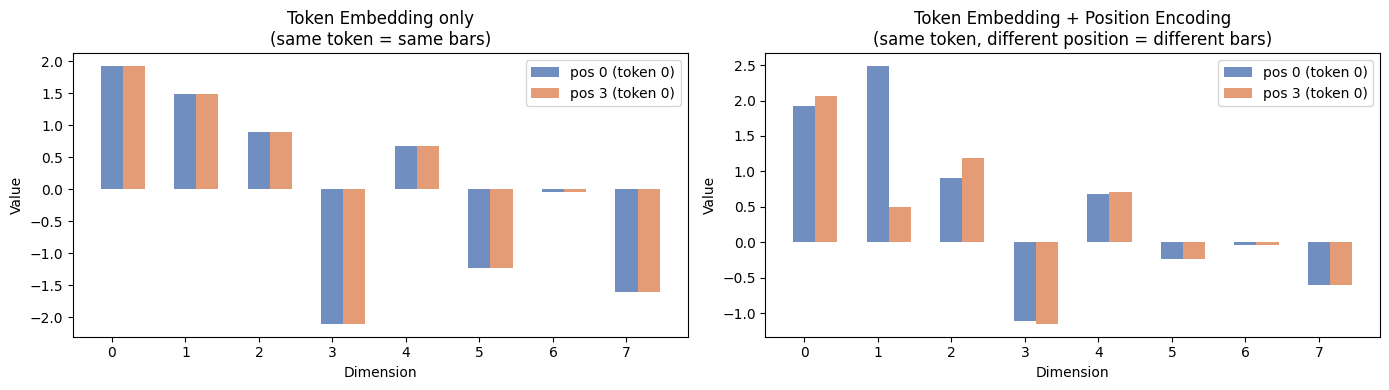

In [8]:
import torch
import matplotlib.pyplot as plt

# 可视化对比：加位置编码前后，同一个 token 在不同位置的向量差异
torch.manual_seed(42)
viz_vocab, viz_dim = 20, 8
viz_module = TokenEmbedding(viz_vocab, viz_dim)

# token 0 出现在位置 0 和位置 3
viz_input = torch.tensor([[0, 1, 2, 0, 3]])

# 只取 token embedding（不加位置编码）
token_only = viz_module.token_emb(viz_input)

# 加上位置编码
with torch.no_grad():
    token_plus_pos = viz_module(viz_input)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 对比 token 0 在位置 0 和位置 3 的向量
positions = [0, 3]  # token 0 出现的两个位置
colors = ['#4C72B0', '#DD8452']
labels = ['pos 0 (token 0)', 'pos 3 (token 0)']

width = 0.3
# 左图：纯 token embedding
for idx, pos in enumerate(positions):
    vals = token_only[0, pos].detach().numpy()
    axes[0].bar([j + idx * width for j in range(viz_dim)], vals,
                width=width, color=colors[idx], label=labels[idx], alpha=0.8)
axes[0].set_title('Token Embedding only\n(same token = same bars)')
axes[0].set_xlabel('Dimension')
axes[0].set_ylabel('Value')
axes[0].legend()

# 右图：token embedding + position encoding
for idx, pos in enumerate(positions):
    vals = token_plus_pos[0, pos].detach().numpy()
    axes[1].bar([j + idx * width for j in range(viz_dim)], vals,
                width=width, color=colors[idx], label=labels[idx], alpha=0.8)
axes[1].set_title('Token Embedding + Position Encoding\n(same token, different position = different bars)')
axes[1].set_xlabel('Dimension')
axes[1].set_ylabel('Value')
axes[1].legend()

plt.tight_layout()
plt.show()

# 数值确认
print("=== 数值确认 ===")
print(f"token 0 在位置 0（纯 Embedding）: {token_only[0, 0, :4].tolist()}")
print(f"token 0 在位置 3（纯 Embedding）: {token_only[0, 3, :4].tolist()}")
print(f"纯 Embedding 时相同? {torch.allclose(token_only[0, 0], token_only[0, 3])}")
print()
print(f"token 0 在位置 0（+ 位置编码）: {token_plus_pos[0, 0, :4].tolist()}")
print(f"token 0 在位置 3（+ 位置编码）: {token_plus_pos[0, 3, :4].tolist()}")
print(f"加位置编码后相同? {torch.allclose(token_plus_pos[0, 0], token_plus_pos[0, 3])}")
print()
print("位置编码解决了开头提出的问题：同一个 token 在不同位置现在有了不同的表示。")


## 附录：Embedding 的缩放惯例

原始 Transformer 论文在查表之后还会乘以 $\sqrt{d\_model}$：

```python
embedding_output = self.token_emb(x) * math.sqrt(d_model)
```

为什么需要这一步？可以把 Embedding 和位置编码的加法想象成两个人同时说话：Embedding 说的是"这个词是什么意思"，位置编码说的是"这个词在第几个位置"。如果两个人音量相当，听的人很难分清主次。

$d\_model = 512$ 时的情况正好印证了这一点。`nn.Embedding` 默认用标准差约 1 的正态分布初始化，每个维度独立抽取，向量的模长大约是 $\sqrt{512} \approx 22.6$。位置编码的值在 $[-1, 1]$ 之间波动，模长大约是 $\sqrt{512 \times 0.5} \approx 16$。两者差距不到两倍——位置信息的"音量"和语义信息在同一个数量级上，直接相加相当于让两个信号平起平坐。

乘以 $\sqrt{512} \approx 22.6$ 之后，Embedding 的模长被放大到约 $512$，而位置编码仍然是 16。此时语义信号的强度约为位置信号的 30 倍——"含义"拿到了麦克风，"位置"退到背景里，只提供微调。这和 Attention 里除以 $\sqrt{d_k}$ 是一个思路：控制量级，让后续的 softmax 和线性层在数值稳定的范围内工作。

GPT-2 和 GPT-3 使用可学习的 position embedding，不依赖这个缩放。后来的模型（如 LLaMA）改用 RoPE 旋转位置编码，同样不需要这个缩放。了解这个惯例有助于阅读原始 Transformer 的实现。

## 附录：Batch 维度

前面代码里的输入形状从 `[seq_len]` 变成了 `[batch_size, seq_len]`。这是因为训练时不会一条一条地算，而是一批一起算。

```
batch_size = 2

样本 0: [the, cat, sat]
样本 1: [dog, log, mat]

合成一个 batch:
[[0, 1, 2],
 [5, 6, 4]]
```

GPU 擅长同时处理很多条样本，batch 就是为了充分利用这一点。

In [9]:
import torch

# 直观感受 batch：一次处理多条样本
batch = torch.tensor([
    [0, 1, 2, 3, 0],  # the cat sat on the
    [5, 4, 6, 1, 2],  # dog mat log cat sat
])

emb_output = emb_module(batch)
print(f"输入形状: {batch.shape} = [batch_size=2, seq_len=5]")
print(f"输出形状: {emb_output.shape} = [2, 5, d_model={test_d_model}]")
print(f"→ GPU 同时算 2 条，比一条一条算快")

输入形状: torch.Size([2, 5]) = [batch_size=2, seq_len=5]
输出形状: torch.Size([2, 5, 8]) = [2, 5, d_model=8]
→ GPU 同时算 2 条，比一条一条算快


## 小结

这一节所学的内容：

- 同一个 token 在不同位置的 Embedding 完全相同——模型需要额外的位置信息来区分顺序
- 直接用位置编号作为位置向量有两个问题：值无限增长，且所有维度信息重复
- 正弦位置编码用不同频率的 sin/cos 波为每个位置生成唯一向量
- sin/cos 的值始终在 [-1, 1] 之间，不会随位置增长而发散
- 训练时没见过的位置也能直接算出正弦编码；这叫“可计算到更长位置”，不等于模型在更长上下文上一定表现好
- 不同频率的波组合起来，低频传递远距离关系，高频区分相邻位置
- 最终输入 = Token Embedding + Position Encoding（加法，维度不变）
- Batch 维度让 GPU 一次处理多条样本，提升训练效率

下一节进入 Self-Attention：有了包含语义和位置信息的向量之后，模型如何让 token 之间互相"看见"。

## 作业

> 可以用 AI 询问思路、拆步骤、检查方向，但不建议直接让 AI "做完这道题"。


### 作业 1：加上位置编码

同一个 token 出现在不同位置时，token embedding 一样；加上 position encoding 后才不同。

小提示：最终输入通常是 `token_vectors + position_vectors`。


In [10]:
import torch

# 作业 1：Token Embedding + Position Encoding 填空
token_vectors = torch.tensor([
    [1.0, 1.0],
    [1.0, 1.0],
])
position_vectors = torch.tensor([
    [0.0, 0.1],
    [0.2, 0.3],
])

# TODO：把下面三引号里的内容替换成你的代码
final_vectors = token_vectors + position_vectors

assert not isinstance(final_vectors, str), "请先替换三引号里的占位内容"
expected = torch.tensor([[1.0, 1.1], [1.2, 1.3]])
assert torch.allclose(final_vectors, expected), final_vectors
assert not torch.allclose(final_vectors[0], final_vectors[1])
print("✅ 作业 2 通过：你记住了位置编码为什么必要")

✅ 作业 2 通过：你记住了位置编码为什么必要


### 作业 2：padding 后的 embedding mask

训练时常把不同长度句子 padding 到同样长度。padding_idx 对应的向量通常不应该影响学习。

小提示：这里先手动把 PAD 位置的向量置零，模拟"忽略 PAD"。


In [11]:
import torch

# 作业 2：PAD 位置向量置零填空
embeddings = torch.tensor([
    [[1.0, 1.0], [2.0, 2.0], [9.0, 9.0], [9.0, 9.0]],
])
attention_mask = torch.tensor([[1, 1, 0, 0]])

# TODO：把下面三引号里的内容替换成你的代码
masked_embeddings = embeddings * attention_mask.unsqueeze(-1)

assert not isinstance(masked_embeddings, str), "请先替换三引号里的占位内容"
expected = torch.tensor([[[1.0, 1.0], [2.0, 2.0], [0.0, 0.0], [0.0, 0.0]]])
assert torch.equal(masked_embeddings, expected), masked_embeddings
print("✅ 作业 3 通过：你理解了 padding 在现代 batch 训练里的处理方式")

✅ 作业 3 通过：你理解了 padding 在现代 batch 训练里的处理方式


**作业 3：正弦位置编码的周期性**正弦位置编码的公式为 $PE(pos, 2i) = \\sin(pos / 10000^{2i/d})$。假设 $d = 4$（2 对维度），计算位置 $pos = 0$ 和 $pos = 10000$ 时，第一对维度（$i=0$）的编码值。观察：第一对维度的周期是多少？（即 $\\sin$ 函数完成一个完整周期需要的 $pos$ 变化量）小提示：$i=0$ 时 $\\theta = pos / 10000^{0} = pos$，所以 $\\sin(pos)$ 的周期是 $2\\pi \\approx 6.28$。

In [12]:
# 作业 3：正弦位置编码的周期性import mathd = 4i = 0# TODO: 计算 pos=0 时的 sin 值pe_0 = None  # sin(0 / 10000^(2*0/4))# TODO: 计算 pos=10000 时的 sin 值pe_10000 = None  # sin(10000 / 10000^(2*0/4))# TODO: 第一对维度的周期period = None  # 2*piassert pe_0 is not Noneassert pe_10000 is not Noneassert period is not Noneassert abs(pe_0 - 0.0) < 0.001assert abs(pe_10000 - math.sin(10000)) < 0.001assert abs(period - 2 * math.pi) < 0.01print(f'pe(0, i=0) = sin(0) = {pe_0:.4f}')print(f'pe(10000, i=0) = sin(10000) = {pe_10000:.4f}')print(f'周期 = {period:.2f}（约 {period:.1f} 个位置）')print('低维度周期短（区分相邻位置），高维度周期长（承载远程关系）。')print(chr(10004) + ' 作业 3 通过')

## 参考资料

- Vaswani et al., [Attention Is All You Need](https://arxiv.org/abs/1706.03762), 2017 — Transformer 原始论文，正弦位置编码和 Embedding 缩放惯例均来自此文
- Harvard NLP, [The Annotated Transformer](https://nlp.seas.harvard.edu/annotated-transformer/) — 对原始论文的逐行实现
- Kazemnejad, [Transformer Architecture: The Positional Encoding](https://kazemnejad.com/transformer_architecture_positional_encoding/) — 正弦位置编码的直觉解释，包括二进制类比

## 附录：正弦位置编码的外推能力

前面提到正弦位置编码可以"外推"——训练时见过 512 个位置，推理时遇到第 513 个位置也能直接算出编码。这并不是理所当然的。要理解为什么，需要对比两种方案的底层机制。

**可学习位置编码的局限。** GPT-2 和 BERT 使用的可学习位置编码（learnable position embedding）本质上是一张查找表：训练时设定 max_seq_len=512，模型就学习 512 个向量，编号 0 到 511。遇到第 513 个位置时，查找表里根本没有这一行——没有学过的向量可以查，也没有合理的默认值可以填。能处理的长度上限在训练时就固定了。GPT-3 也使用这种方案，它的上下文窗口长度（2048）就是在训练阶段确定的，推理时无法突破。

**正弦位置编码的优势。** 它的编码由公式直接计算：PE(pos) = sin(pos / 10000^(2i/d))。不管 pos 是 100 还是 100000，只要代入公式就能得到一个有效向量。查找表和公式的区别，就像一本只有 512 页的字典和一套造词规则：字典里查不到的词就没辙，但造词规则对任何词都能给出一个结果。

从另一个角度看，正弦编码还有一项数学性质：位置 pos 的编码和位置 pos+k 的编码之间存在确定的线性关系（来自三角恒等式 $\sin(a+b) = \sin a \cos b + \cos a \sin b$）。这意味着模型在训练时学到的"相邻位置之间的编码差异模式"，在超出训练长度后仍然成立。可学习编码则没有这种结构——位置 511 和位置 512 之间的向量关系完全取决于训练时学到的参数，没有先验规律可循。

**需要说明的局限。** "编码能算出来"不等于"模型在更长序列上表现一样好"。训练时模型只见过 512 个位置范围内的编码模式，超出这个范围后，注意力权重、层归一化等模块的统计特性可能发生变化。正弦编码提供了数学上的可计算性，但实际的外推效果仍然取决于模型的整体设计。

正因如此，后来的研究提出了多种改进方案。ALiBi 直接在 Attention 分数上加一个随距离线性增长的偏置，公式本身没有长度上限，外推能力比正弦编码更强。RoPE（Rotary Position Embedding）用旋转矩阵编码相对位置，被 LLaMA、Mistral 等主流模型采用，配合位置插值技术可以将上下文窗口扩展到训练长度的数倍。这些方案的设计初衷之一，就是让位置编码在更长的序列上依然有效。